# Sentiment Analysis of Death Row Inmates' Last Words 

**Author**: Piotr Sikora

**Topic**: Text Classification with Transformer Fine-Tuning

**Dataset**: Texas Department of Criminal Justice (TDCJ) Executed Offenders List

In [82]:
# web scraping
import os
import re
import requests
from bs4 import BeautifulSoup as bs

# data handling
import numpy as np
import pandas as pd
from collections import Counter

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# huggingface transformers
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import (
    DistilBertTokenizer,
    DistilBertModel,
    pipeline
)

# pytorch utilities
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

# scipy
from scipy.spatial.distance import jensenshannon
from scipy.stats import pearsonr
from scipy.cluster.hierarchy import linkage, dendrogram

# utilities
from tqdm import tqdm

In [ ]:
# reproducibility
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)


# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## Data
### Scraping the TDCJ Website

In [4]:
URL  = "https://www.tdcj.texas.gov/death_row/dr_executed_offenders.html"
page = requests.get(URL)
parsed_page = bs(page.content, 'html.parser')

table = parsed_page.find("table", {"class": "tdcj_table"})
rows = table.find_all("tr")
rows = rows[1:] # skip the header
quotes = []

for row in rows:
    dr_url = row.find_all("td")[2].find("a")["href"]
    dr_url = dr_url.replace("/death_row/", "", 1) if dr_url.startswith("/death_row/") else dr_url 
    dr_url = "https://www.tdcj.texas.gov/death_row/" + dr_url
    dr_page = requests.get(dr_url)
    parsed_dr_page = bs(dr_page.content, 'html.parser')
    last_words_found = parsed_dr_page.find("div", {"id": "content_right"}).find_all("p")[5:]
    last_words =  " ".join([p.text.strip() for p in last_words_found if len(p.text.strip()) > 0])
    if len(last_words) > 0:
        quotes.append(last_words)

print(f"Collected {len(quotes)} quotes.")

df = pd.DataFrame(quotes, columns=["last_words"])
df.to_csv("texas_death_row_quotes.csv", index=False)

Collected 494 quotes.


In [3]:
df = pd.read_csv("texas_death_row_quotes.csv").dropna()
print(f"Number of quotes: {len(df)}")
df.sample(10)

Number of quotes: 492


,last_words
80,"Nesha, I love you. I hope this brings you some..."
56,"Yes, I made peace with God. I hope y'all make ..."
274,"The statement that I would like to make is, no..."
288,I want to say God forgives as I forgive. God i...
65,"Yes, I would like to thank all of my supporter..."
184,"I want you all to know, everyone with all my h..."
31,"Yeah, I want to address the Roundtree family ..."
119,"To the family of Alyssa Vazquez, I hope you wi..."
466,None. But as he lay there he did praise the Lo...
338,I want the victim's family to know that I didn...


The dataset is small and contains only the final quotes of death row inmates. Some entries say “no statement given". From limited experiments on the Hugging Face website, the ```j-hartmann/emotion-english-distilroberta-base``` model labels these mostly as neutral or sad. I chose to keep all entries, including these cases. Keeping them preserves the full dataset and treats silence as meaningful information.

### EDA
Word count and text length counts

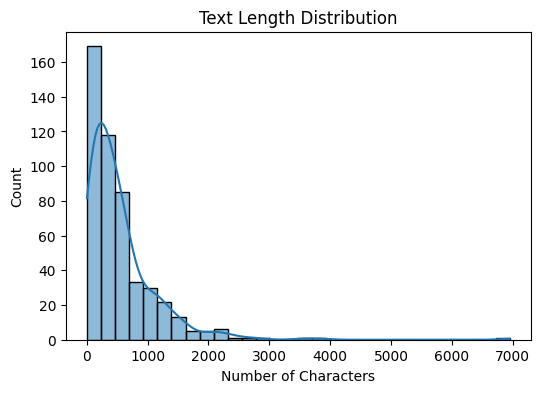

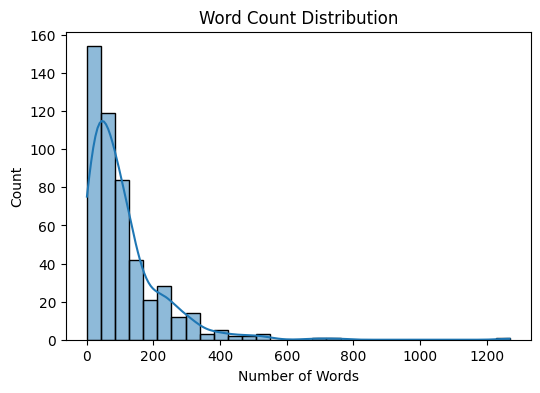

In [4]:
df = pd.read_csv("texas_death_row_quotes.csv").dropna()

df['text_length'] = df['last_words'].apply(len)
df['word_count'] = df['last_words'].apply(lambda x: len(x.split()))


plt.figure(figsize=(6,4))
sns.histplot(df['text_length'], bins=30, kde=True)
plt.title("Text Length Distribution")
plt.xlabel("Number of Characters")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(df['word_count'], bins=30, kde=True)
plt.title("Word Count Distribution")
plt.xlabel("Number of Words")
plt.show()


In [5]:
df['word_count'].describe()

count     492.000000
mean      107.983740
std       117.053105
min         1.000000
25%        32.750000
50%        75.000000
75%       137.250000
max      1268.000000
Name: word_count, dtype: float64

There are some quotes that most likely exceed the maximum token length of 512 for DistilBERT, assuming a token is ~0.75 of a word. We need to filter those out before we can use the tokenizer.

### Most frequentyly used words

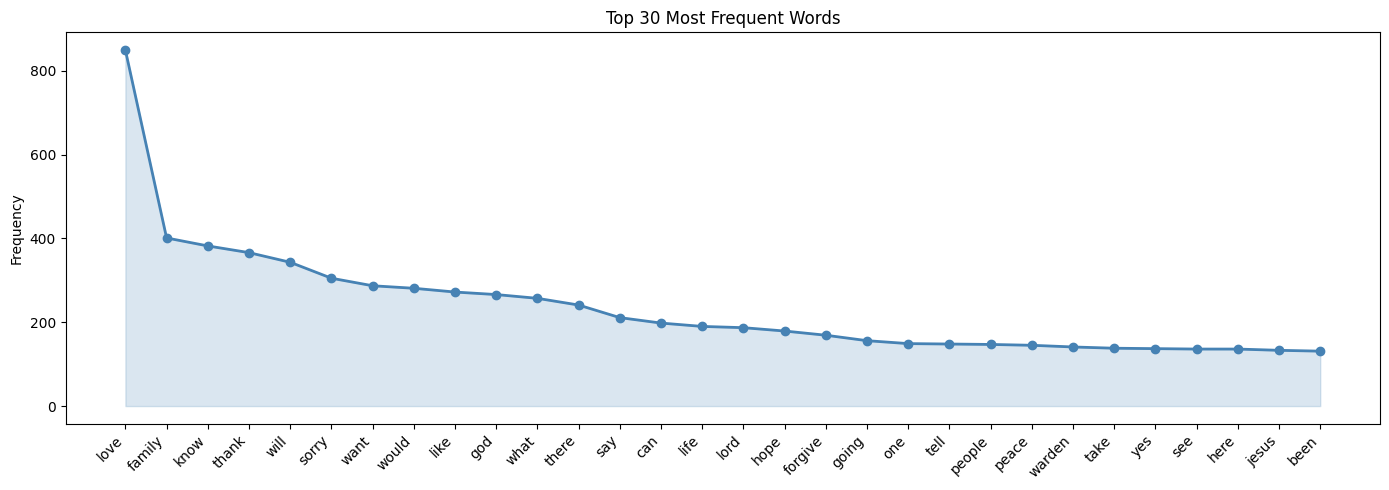

In [6]:
stop_words = set(['the','a','an','and','or','but','in','on','at','to','for',
                  'of','with','i','my','me','that','is','was','it','this',
                  'have','be','as','you','we','they','he','she','his','her',
                  'all','are','not','so','do','just','no','if','your','our',
                  'them','don','did','who'])

words = []
for text in df['last_words']:
    tokens = re.findall(r'\b[a-z]+\b', text.lower())
    words.extend([w for w in tokens if (w not in stop_words and len(w) > 2)])

word_freq = Counter(words).most_common(30)
words_list, counts = zip(*word_freq)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(words_list, counts, marker='o', linewidth=2, color='steelblue')
ax.fill_between(range(len(words_list)), counts, alpha=0.2, color='steelblue')
ax.set_xticks(range(len(words_list)))
ax.set_xticklabels(words_list, rotation=45, ha='right')
ax.set_title('Top 30 Most Frequent Words')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

- The most frequent words are strongly emotional and relational (e.g., love, family, thank, sorry, forgive, peace).
- Religious words appear often (e.g., god, lord, jesus), suggesting spirituality is common in final statements.
- Many words reflect reflection or awareness (e.g., know, life, hope).
- Some words relate to the execution setting itself (e.g., warden, take).

Overall, the most common words suggest themes of love, apology, faith, and closure.

### Cleaning and Preprocessing

The maximum sequence of tokens for DistilBERT is 512. We want to preserve as many quotes as possible, so instead of guessing that one token is exactly one word, we'll put all of our quotes through the tokenizer and keep the ones that don't exceed 512 tokens.

In [7]:
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

encoded = tokenizer(
    df['last_words'].tolist(),
    add_special_tokens=True,
    truncation=False
)

mask = [len(ids) <= 512 for ids in encoded["input_ids"]]
df['is_valid'] = mask
valid_count = df['is_valid'].sum()  
print(f"Number of valid quotes (<= 512 tokens): {valid_count} out of {len(df)}")

Token indices sequence length is longer than the specified maximum sequence length for this model (568 > 512). Running this sequence through the model will result in indexing errors


Number of valid quotes (<= 512 tokens): 481 out of 492


Only ~2% of all quotes were over the token limit. That's great news!

Now we'll normalize our text.

In [8]:
def normalize_for_model(text):
    if not isinstance(text, str):
        return None
    
    # normalize whitespace and newlines
    text = re.sub(r'\s+', ' ', text).strip()
    
    # normalize curly quotes and apostrophes
    text = text.replace('\u2018', "'").replace('\u2019', "'")
    text = text.replace('\u201c', '"').replace('\u201d', '"')
    
    return text

df['normalized_text'] = df['last_words'].apply(normalize_for_model)

df_clean = df[df['is_valid']].copy()
print(f"Number of quotes after cleaning: {len(df_clean)}")

Number of quotes after cleaning: 481


In [9]:
df_clean.head()

,last_words,text_length,word_count,is_valid,normalized_text
0,"Yes, I would like to say that I hope the victi...",532,102,True,"Yes, I would like to say that I hope the victi..."
1,I would like to give a special thanks to all o...,574,114,True,I would like to give a special thanks to all o...
2,"First and foremost, I would like to give all p...",1634,317,True,"First and foremost, I would like to give all p..."
3,"To Mark, Pam, Austin, Uncle Troy, and Jose, I ...",562,113,True,"To Mark, Pam, Austin, Uncle Troy, and Jose, I ..."
4,There is not a day that goes by that I don't r...,1571,310,True,There is not a day that goes by that I don't r...


## Labeling 

In [10]:
teacher = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    return_all_scores=True,
    device=0 if torch.cuda.is_available() else -1
)

EMOTION_LABELS = ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']

def get_soft_labels(text):
    scores = teacher(text)[0]
    # sort alphabetically to ensure consistent vector ordering
    scores = sorted(scores, key=lambda x: x['label'])
    return [round(s['score'], 6) for s in scores]

def get_hard_label(soft_label):
    """Returns argmax of soft distribution for baseline model"""
    return int(np.argmax(soft_label))

df_clean['soft_labels'] = df_clean['normalized_text'].apply(get_soft_labels)
df_clean['hard_label']  = df_clean['soft_labels'].apply(get_hard_label)
df_clean['dominant_emotion'] = df_clean['hard_label'].apply(lambda x: EMOTION_LABELS[x])

print(df_clean['dominant_emotion'].value_counts())

Device set to use cpu
c:\Users\User\anaconda3\Lib\site-packages\transformers\pipelines\text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


dominant_emotion
sadness    189
neutral    118
joy        106
anger       45
disgust     12
fear        11
Name: count, dtype: int64


Interesting fact worth noting - the labeling model didn't find any death row inmate to be mostly suprised. We'll consider if that emotion is worth modelling.

In [12]:
df_clean['surprise_score'] = df_clean['soft_labels'].apply(lambda x: x[6])

df_sorted = df_clean.sort_values(
    by='surprise_score',
    ascending=False
)

def get_surprise_rank(soft_label):
    sorted_indices = np.argsort(soft_label)[::-1]  # descending
    rank = np.where(sorted_indices == 6)[0][0] + 1
    return rank

df_clean['surprise_rank'] = df_clean['soft_labels'].apply(get_surprise_rank)

df_sorted[['normalized_text', 'surprise_score','surprise_rank', 'dominant_emotion']].head()

,normalized_text,surprise_score,surprise_rank,dominant_emotion
196,"Uh, I don't know, Um, I don't know what to say...",0.276974,2,disgust
112,"Bohannon, Peg and Kim, I love ya'll. Son, get ...",0.101573,4,neutral
358,"Dad, I love you both. You've been the best. Al...",0.082668,4,sadness
464,Thanked his family.,0.074446,3,joy
110,"Yes, you know I sat in my cell many days wonde...",0.067468,3,fear


In [13]:
print(df_clean['surprise_rank'].value_counts().sort_index())

surprise_rank
2      3
3     25
4     86
5     71
6    145
7    151
Name: count, dtype: int64


We'll get rid of those 2 "highly suprised" quotes. "Suprised" isn't a primary feeling to any of the last words.

We'll remove "suprised" as a target label and renormalize the distributions.

In [14]:
df_clean = df_clean[df_clean['surprise_score'] < 0.1].copy()

def normalize_dist(soft_label):
    new_soft_label = soft_label[:6] 
    total = sum(new_soft_label)
    if total == 0:
        return [0] * len(new_soft_label)
    return [round(s / total,6) for s in new_soft_label]

EMOTION_LABELS = ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness']
df_clean['norm_soft'] = df_clean['soft_labels'].apply(normalize_dist) 
df_clean['norm_hard']  = df_clean['norm_soft'].apply(get_hard_label)
df_clean['dominant_emotion'] = df_clean['hard_label'].apply(lambda x: EMOTION_LABELS[x])


In [15]:
df_final = df_clean[['normalized_text', 'norm_soft', 'norm_hard', 'dominant_emotion']]
df_final.rename(columns={'normalized_text': 'text',"norm_soft": "soft_labels", "norm_hard": "hard_label"}, inplace=True)
print(df_final[['soft_labels', 'hard_label', 'dominant_emotion']].shape)
df_final.to_csv("death_row_labeled.csv", index=False) 

(479, 3)


## Dataset Split

In [16]:
# df_final = pd.read_csv("death_row_labeled.csv")
train_df, temp_df = train_test_split(df_final, test_size=0.2, stratify=df_final['dominant_emotion'], random_state=42)
val_df,   test_df = train_test_split(temp_df,  test_size=0.5, stratify=temp_df['dominant_emotion'], random_state=42)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Train: 383, Val: 48, Test: 48


## Dataset and Dataloader

In [18]:
class StatementDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=512):
        self.encodings = tokenizer(
            df['text'].tolist(),
            max_length=max_length,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )
        self.soft_labels = torch.tensor(df['soft_labels'].tolist(), dtype=torch.float32)
        self.hard_labels = torch.tensor(df['hard_label'].tolist(),  dtype=torch.long)
    
    def __len__(self):
        return len(self.hard_labels)
    
    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'soft_labels':    self.soft_labels[idx],
            'hard_labels':    self.hard_labels[idx]
        }

train_dataset = StatementDataset(train_df, tokenizer)
val_dataset   = StatementDataset(val_df,   tokenizer)
test_dataset  = StatementDataset(test_df,  tokenizer)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=8)
test_loader  = DataLoader(test_dataset,  batch_size=8)

## Model Training

In [ ]:
class BaselineClassifier(nn.Module):
    """
    Frozen DistilBERT encoder with a single trainable linear head.
    Trained with CrossEntropyLoss on hard labels (argmax of j-hartmann output).
    Only ~200K parameters are trained.
    """
    def __init__(self, num_labels=6):
        super().__init__()
        self.bert = DistilBertModel.from_pretrained("distilbert-base-uncased")
        
        for param in self.bert.parameters():
            param.requires_grad = False
        
        self.classifier = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_labels)
        )
    
    def forward(self, input_ids, attention_mask):
        with torch.no_grad():
            outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_token = outputs.last_hidden_state[:, 0, :]  # CLS token pooling
        return self.classifier(cls_token)
    
    def count_trainable_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)
    
class DistillationClassifier(nn.Module):
    """
    Fully fine-tuned DistilBERT trained with KL divergence loss
    against j-hartmann's soft probability distributions.
    All ~67M parameters are trained.
    """
    def __init__(self, num_labels=6):
        super().__init__()
        self.bert = DistilBertModel.from_pretrained("distilbert-base-uncased")
        
        self.classifier = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_labels)
        )
    
    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_token = outputs.last_hidden_state[:, 0, :]
        return self.classifier(cls_token)
    
    def count_trainable_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


class CrossEntropyLossHard(nn.Module):
    """
    Standard cross entropy for baseline model.
    Targets are hard integer class indices (argmax of teacher distribution).
    """
    def __init__(self):
        super().__init__()
        self.loss = nn.CrossEntropyLoss()
    
    def forward(self, logits, hard_labels):
        return self.loss(logits, hard_labels)


class KLDivergenceLoss(nn.Module):
    """
    KL divergence loss for distillation model.
    Targets are soft probability distributions from j-hartmann.
    """
    def __init__(self):
        super().__init__()
        self.loss = nn.KLDivLoss(reduction="batchmean")
    
    def forward(self, logits, soft_labels):
        # KLDivLoss expects log-probabilities as input, probabilities as target
        log_probs = nn.functional.log_softmax(logits, dim=-1)
        return self.loss(log_probs, soft_labels)


baseline_model    = BaselineClassifier(num_labels=6).to(device)
distillation_model = DistillationClassifier(num_labels=6).to(device)

baseline_loss    = CrossEntropyLossHard()
distillation_loss = KLDivergenceLoss()

print(f"Baseline trainable params:     {baseline_model.count_trainable_params():,}")
print(f"Distillation trainable params: {distillation_model.count_trainable_params():,}")

# dummy forward pass to confirm shapes
dummy_ids  = torch.randint(0, 1000, (2, 512)).to(device)
dummy_mask = torch.ones(2, 512, dtype=torch.long).to(device)

baseline_out     = baseline_model(dummy_ids, dummy_mask)
distillation_out = distillation_model(dummy_ids, dummy_mask)

print(f"Baseline output shape:     {baseline_out.shape}")     # (2, 7)
print(f"Distillation output shape: {distillation_out.shape}") # (2, 7)

# test losses
dummy_hard   = torch.randint(0, 6, (2,)).to(device)
dummy_soft   = nn.functional.softmax(torch.randn(2, 6), dim=-1).to(device)

print(f"Cross entropy loss: {baseline_loss(baseline_out, dummy_hard).item():.4f}")
print(f"KL divergence loss: {distillation_loss(distillation_out, dummy_soft).item():.4f}")

Baseline trainable params:     198,406
Distillation trainable params: 66,561,286
Baseline output shape:     torch.Size([2, 6])
Distillation output shape: torch.Size([2, 6])
Cross entropy loss: 1.7947
KL divergence loss: 0.5431


In [26]:
def train(model, optimizer, loss_fn, train_loader, val_loader,
          label_key, epochs=5, device='cpu'):
    
    history = {'train_loss': [], 'val_loss': []}
    
    for epoch in range(epochs):
        # -- train
        model.train()
        train_losses = []

        train_bar = tqdm(train_loader, 
                         desc=f"Epoch {epoch+1}/{epochs} [Train]",
                         leave=False)

        for batch in train_bar:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch[label_key].to(device)
            
            optimizer.zero_grad()
            logits = model(input_ids, attention_mask)
            loss   = loss_fn(logits, labels)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
            train_bar.set_postfix({'loss': f"{loss.item():.4f}"})            
        
        # -- validate
        model.eval()
        val_losses = []

        val_bar = tqdm(val_loader,
                       desc=f"Epoch {epoch+1}/{epochs} [Val]  ",
                       leave=False)

        with torch.no_grad():
            for batch in val_bar:
                input_ids      = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels         = batch[label_key].to(device)
                logits         = model(input_ids, attention_mask)
                batch_val_loss = loss_fn(logits, labels).item()
                val_losses.append(batch_val_loss)
                val_bar.set_postfix({'loss': f"{batch_val_loss:.4f}"})
                
        train_loss = np.mean(train_losses)
        val_loss   = np.mean(val_losses)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    
    return history


baseline_optimizer = AdamW(
    filter(lambda p: p.requires_grad, baseline_model.parameters()), lr=1e-3
)
baseline_history = train(
    baseline_model, baseline_optimizer,
    baseline_loss, train_loader, val_loader,
    label_key='hard_labels', epochs=5, device=device
)

distill_optimizer = AdamW(distillation_model.parameters(), lr=2e-5)
distill_history = train(
    distillation_model, distill_optimizer,
    distillation_loss, train_loader, val_loader,
    label_key='soft_labels', epochs=5, device=device
)

Epoch 1/5 | Train Loss: 1.2470 | Val Loss: 1.1998


Epoch 2/5 | Train Loss: 1.1887 | Val Loss: 1.1819


Epoch 3/5 | Train Loss: 1.1381 | Val Loss: 1.1608


Epoch 4/5 | Train Loss: 1.0643 | Val Loss: 1.1674


Epoch 5/5 | Train Loss: 1.0498 | Val Loss: 1.1250


Epoch 1/5 | Train Loss: 0.7688 | Val Loss: 0.6555


Epoch 2/5 | Train Loss: 0.5301 | Val Loss: 0.4837


Epoch 3/5 | Train Loss: 0.3524 | Val Loss: 0.4669


Epoch 4/5 | Train Loss: 0.2405 | Val Loss: 0.5033


Epoch 5/5 | Train Loss: 0.1931 | Val Loss: 0.4849


In [ ]:
os.makedirs("models", exist_ok=True)

torch.save(baseline_model.state_dict(),     "models/baseline_model.pth")
torch.save(distillation_model.state_dict(), "models/distillation_model.pth")

print("Models saved.")

Models saved.


In [ ]:
baseline_model.load_state_dict(torch.load("models/baseline_model.pth",     map_location=device))
distillation_model.load_state_dict(torch.load("models/distillation_model.pth", map_location=device))

print("Models loaded.")


def extract_embeddings_and_preds(model, loader, device):
    model.eval()
    embeddings, soft_preds, soft_targets, hard_targets = [], [], [], []
    
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            
            # get CLS token embedding before classifier head
            outputs = model.bert(input_ids=input_ids, attention_mask=attention_mask)
            cls_emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            
            # get predicted distribution
            logits = model(input_ids, attention_mask)
            probs  = nn.functional.softmax(logits, dim=-1).cpu().numpy()
            
            embeddings.append(cls_emb)
            soft_preds.append(probs)
            soft_targets.extend(batch['soft_labels'].numpy())
            hard_targets.extend(batch['hard_labels'].numpy())
    
    return (np.vstack(embeddings), np.vstack(soft_preds),
            np.array(soft_targets), np.array(hard_targets))


Models loaded.


## Visualisations and Summary

### Training Curves

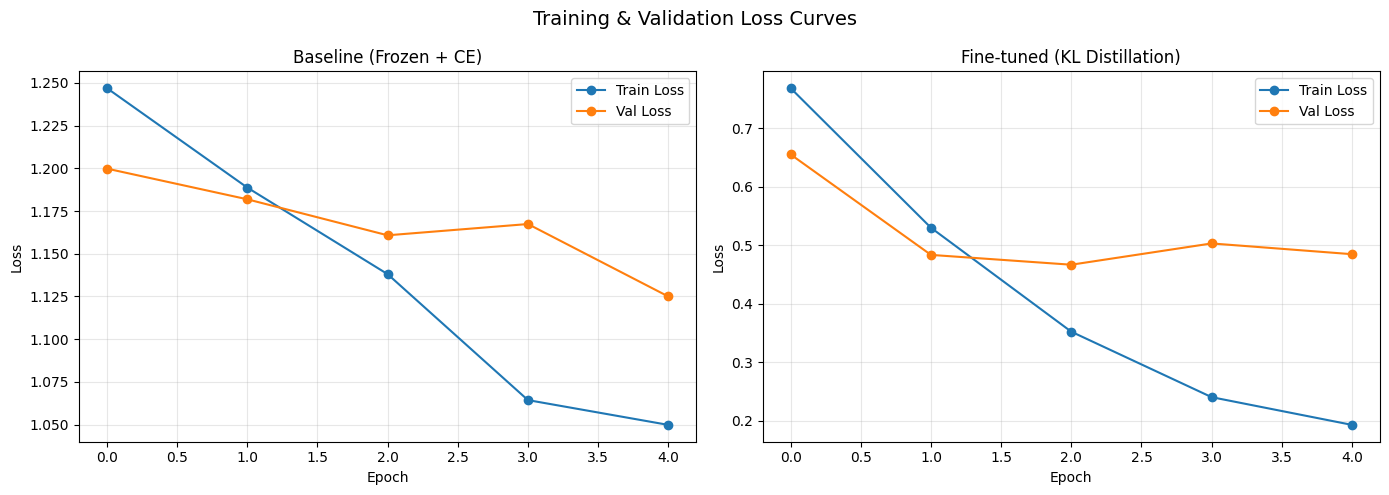

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, history, title in zip(axes,
                               [baseline_history, distill_history],
                               ['Baseline (Frozen + CE)', 'Fine-tuned (KL Distillation)']):
    ax.plot(history['train_loss'], label='Train Loss', marker='o')
    ax.plot(history['val_loss'],   label='Val Loss',   marker='o')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Training & Validation Loss Curves', fontsize=14)
plt.tight_layout()
plt.show()

- **Baseline (Frozen + CE)**: Train and val loss are close together and both declining steadily. This is healthy behaviour for a frozen model - the linear head is learning without overfitting because there are very few trainable parameters. The gap between train and val is small. 5 epochs wasn't enough to converge, it still has room to go.
- **Fine-tuned (KL Distillation)** - right: Classic overfitting pattern. Train loss drops aggressively (0.8 → 0.2) while val loss plateaus around 0.45-0.5 after epoch 2 and stops improving. This is almost inevitable with ~383 training samples and 67M trainable parameters - the model memorizes the training set.

### Error Analysis

In [71]:
def get_predictions(model, loader, device):
    model.eval()
    all_probs, all_soft, all_hard, all_texts = [], [], [], []
    
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            logits         = model(input_ids, attention_mask)
            probs          = F.softmax(logits, dim=-1).cpu().numpy()
            
            all_probs.extend(probs)
            all_soft.extend(batch['soft_labels'].numpy())
            all_hard.extend(batch['hard_labels'].numpy())
    
    return np.array(all_probs), np.array(all_soft), np.array(all_hard)

base_preds, soft_targets, hard_targets = get_predictions(baseline_model,     test_loader, device)
dist_preds, _,            _            = get_predictions(distillation_model, test_loader, device)

# recover original texts from test split
test_texts = test_df['text'].reset_index(drop=True)

error_df = pd.DataFrame({
    'text':               test_texts,
    'true_emotion':       [EMOTION_LABELS[i] for i in hard_targets],
    'base_pred':          [EMOTION_LABELS[np.argmax(p)] for p in base_preds],
    'dist_pred':          [EMOTION_LABELS[np.argmax(p)] for p in dist_preds],
    'base_js':            [jensenshannon(soft_targets[i], base_preds[i]) for i in range(len(base_preds))],
    'dist_js':            [jensenshannon(soft_targets[i], dist_preds[i]) for i in range(len(dist_preds))],
    'base_top1_correct':  [np.argmax(base_preds[i]) == hard_targets[i] for i in range(len(base_preds))],
    'dist_top1_correct':  [np.argmax(dist_preds[i]) == hard_targets[i] for i in range(len(dist_preds))],
    'teacher_dist':       list(soft_targets),
    'base_dist':          list(base_preds),
    'dist_dist':          list(dist_preds),
})

**BEST PREDICTIONS** - lowest JS divergence

In [73]:
print("=" * 80)
print("TOP 3 BEST PREDICTIONS - Fine-tuned (lowest JS divergence from teacher)")
print("=" * 80)
best = error_df.nsmallest(3, 'dist_js')

for _, row in best.iterrows():
    print(f"\nText:        {row['text']}" )
    print(f"True emotion:    {row['true_emotion']}")
    print(f"Fine-tuned pred: {row['dist_pred']}  (JS: {row['dist_js']:.4f})")
    print(f"Baseline pred:   {row['base_pred']}  (JS: {row['base_js']:.4f})")
    
    # show full distribution comparison
    dist_data = pd.DataFrame({
        'Teacher':   row['teacher_dist'],
        'Fine-tuned': row['dist_dist'],
        'Baseline':  row['base_dist']
    }, index=EMOTION_LABELS).round(3)
    print(dist_data.to_string())

TOP 3 BEST PREDICTIONS - Fine-tuned (lowest JS divergence from teacher)

Text:        Yes Sir, that will be five Dollars I love you, I love you, and I love you. Mike I love you. Where's Nelley at? I love you. That will be five dollars. Take Care."
True emotion:    joy
Fine-tuned pred: joy  (JS: 0.0540)
Baseline pred:   neutral  (JS: 0.4344)
         Teacher  Fine-tuned  Baseline
anger      0.017       0.012     0.041
disgust    0.010       0.016     0.026
fear       0.004       0.009     0.017
joy        0.838       0.821     0.251
neutral    0.096       0.084     0.541
sadness    0.036       0.058     0.124

Text:        I guess the first thing I want to do is thank some very special people, Sara and Sabrina. And for affording me the opportunity that ya'll did. It made a real big difference in my life. I thank you. Thank you again from the deepest part of my heart. I'm sorry. The biggest thing I wanted to say was to you and family and I know I haven't had a chance to talk with ya'll i

The three best predictions reveal where domain adaptation adds the most value. In the first case ("I love you... that will be five dollars"), the fine-tuned model correctly identifies joy with near-perfect distribution matching (JS: 0.054), while the frozen baseline misclassifies it as neutral entirely - suggesting that the baseline's generic embeddings cannot distinguish emotional warmth from neutral phrasing without fine-tuning. The second and third cases are long, reflective statements involving apology, forgiveness, and farewell - the fine-tuned model matches the teacher's sadness distribution significantly better than the baseline in both, indicating it has learned to associate the specific vocabulary of remorse and reconciliation ("I'm sorry", "forgive me", "I regret") with sadness in this domain.

**WORST PREDICTIONS** - highest JS divergence 

In [74]:
print("\n" + "=" * 80)
print("TOP 3 WORST PREDICTIONS - Fine-tuned (highest JS divergence from teacher)")
print("=" * 80)
worst = error_df.nlargest(3, 'dist_js')

for _, row in worst.iterrows():
    print(f"\nText:            {row['text']}")
    print(f"True emotion:    {row['true_emotion']}")
    print(f"Fine-tuned pred: {row['dist_pred']}  (JS: {row['dist_js']:.4f})")
    print(f"Baseline pred:   {row['base_pred']}  (JS: {row['base_js']:.4f})")
    
    dist_data = pd.DataFrame({
        'Teacher':    row['teacher_dist'],
        'Fine-tuned': row['dist_dist'],
        'Baseline':   row['base_dist']
    }, index=EMOTION_LABELS).round(3)
    print(dist_data.to_string())


TOP 3 WORST PREDICTIONS - Fine-tuned (highest JS divergence from teacher)

Text:            The Lord is my Shepherd, I shall not want. He maketh me lie down in green pastures; He leadeth me beside the still waters, He restoreth my soul. He leadeth me in the paths of righteousness for His name's sake. Yea, though I walk through the valley of the shadow of death, I will fear no evil; for Thou art with me. Thy rod and Thy staff, they comfort me. Thou preparest a table before me, in the presence of mine enemies. He anointeth my head with oil; my cup runneth over. Surely goodness and mercy shall follow me all the days of my life, and I will dwell in the House of the Lord forever. Amen. Amen.
True emotion:    fear
Fine-tuned pred: neutral  (JS: 0.7146)
Baseline pred:   neutral  (JS: 0.7036)
         Teacher  Fine-tuned  Baseline
anger      0.011       0.127     0.223
disgust    0.011       0.070     0.024
fear       0.945       0.041     0.049
joy        0.004       0.068     0.141
neutral 

All three worst cases share a common failure mode: both models collapse to neutral when the teacher assigned a strong non-neutral emotion. The 23rd Psalm recitation is labeled fear by the teacher, yet both models predict neutral - likely because the text is liturgically calm and contains no explicit emotional language, making it genuinely ambiguous even for a human reader. The "I'm gonna go to sleep" case is labeled disgust, which is arguably a questionable teacher label itself, suggesting j-hartmann may have mislabeled it. The "Lock and load" case is short and colloquial - both models struggle with very short statements lacking contextual richness, which is a known limitation of transformer models on minimal input. These worst cases are largely explainable by either label noise from the teacher or inherent textual ambiguity, rather than model failure.

**DISAGREEMENT** - where models differ from each other 

In [75]:
print("\n" + "=" * 80)
print("MODEL DISAGREEMENTS - fine-tuned and baseline predict different emotions")
print("=" * 80)
disagreements = error_df[error_df['base_pred'] != error_df['dist_pred']]
print(f"Total disagreements: {len(disagreements)} / {len(error_df)}")

for _, row in disagreements.head(3).iterrows():
    print(f"\nText:            {row['text']}...")
    print(f"Teacher label:   {row['true_emotion']}")
    print(f"Baseline pred:   {row['base_pred']}  (JS: {row['base_js']:.4f})")
    print(f"Fine-tuned pred: {row['dist_pred']}  (JS: {row['dist_js']:.4f})")
    
    dist_data = pd.DataFrame({
        'Teacher':    row['teacher_dist'],
        'Fine-tuned': row['dist_dist'],
        'Baseline':   row['base_dist']
    }, index=EMOTION_LABELS).round(3)
    print(dist_data.to_string())


MODEL DISAGREEMENTS - fine-tuned and baseline predict different emotions
Total disagreements: 16 / 48

Text:            To the media, I would like for you to tell all the victims and their loved ones that I am truly, truly sorry for taking their loved ones' lives. And I hope they will find it in their heart to forgive me for what I did to them. I am a different person now, but that does not change the fact of the bad things I have committed. God can give you the same peace He gave me and you can be in His hands. And to my beautiful family, be strong. Remember what I said, "God is the Way, the Truth, and the Life." OK, Warden....
Teacher label:   sadness
Baseline pred:   neutral  (JS: 0.4195)
Fine-tuned pred: sadness  (JS: 0.1081)
         Teacher  Fine-tuned  Baseline
anger      0.004       0.019     0.134
disgust    0.023       0.025     0.016
fear       0.005       0.013     0.016
joy        0.011       0.020     0.200
neutral    0.145       0.069     0.338
sadness    0.812       0.

Of 48 test samples, 16 produced different predictions between the two models - a 33% disagreement rate, which is substantial. In all three shown examples the fine-tuned model produces lower JS divergence, meaning it agrees more closely with the teacher. The pattern is consistent: the baseline defaults to neutral for emotionally complex statements, while the fine-tuned model correctly resolves them into sadness or joy. The third disagreement is the most interesting - a statement of gratitude and praise labeled neutral by the teacher, where the baseline predicts sadness and the fine-tuned model predicts joy. Neither is obviously wrong, and the teacher's neutral label is debatable, illustrating that the emotional register of death row statements is genuinely difficult to classify even for a strong pretrained model.

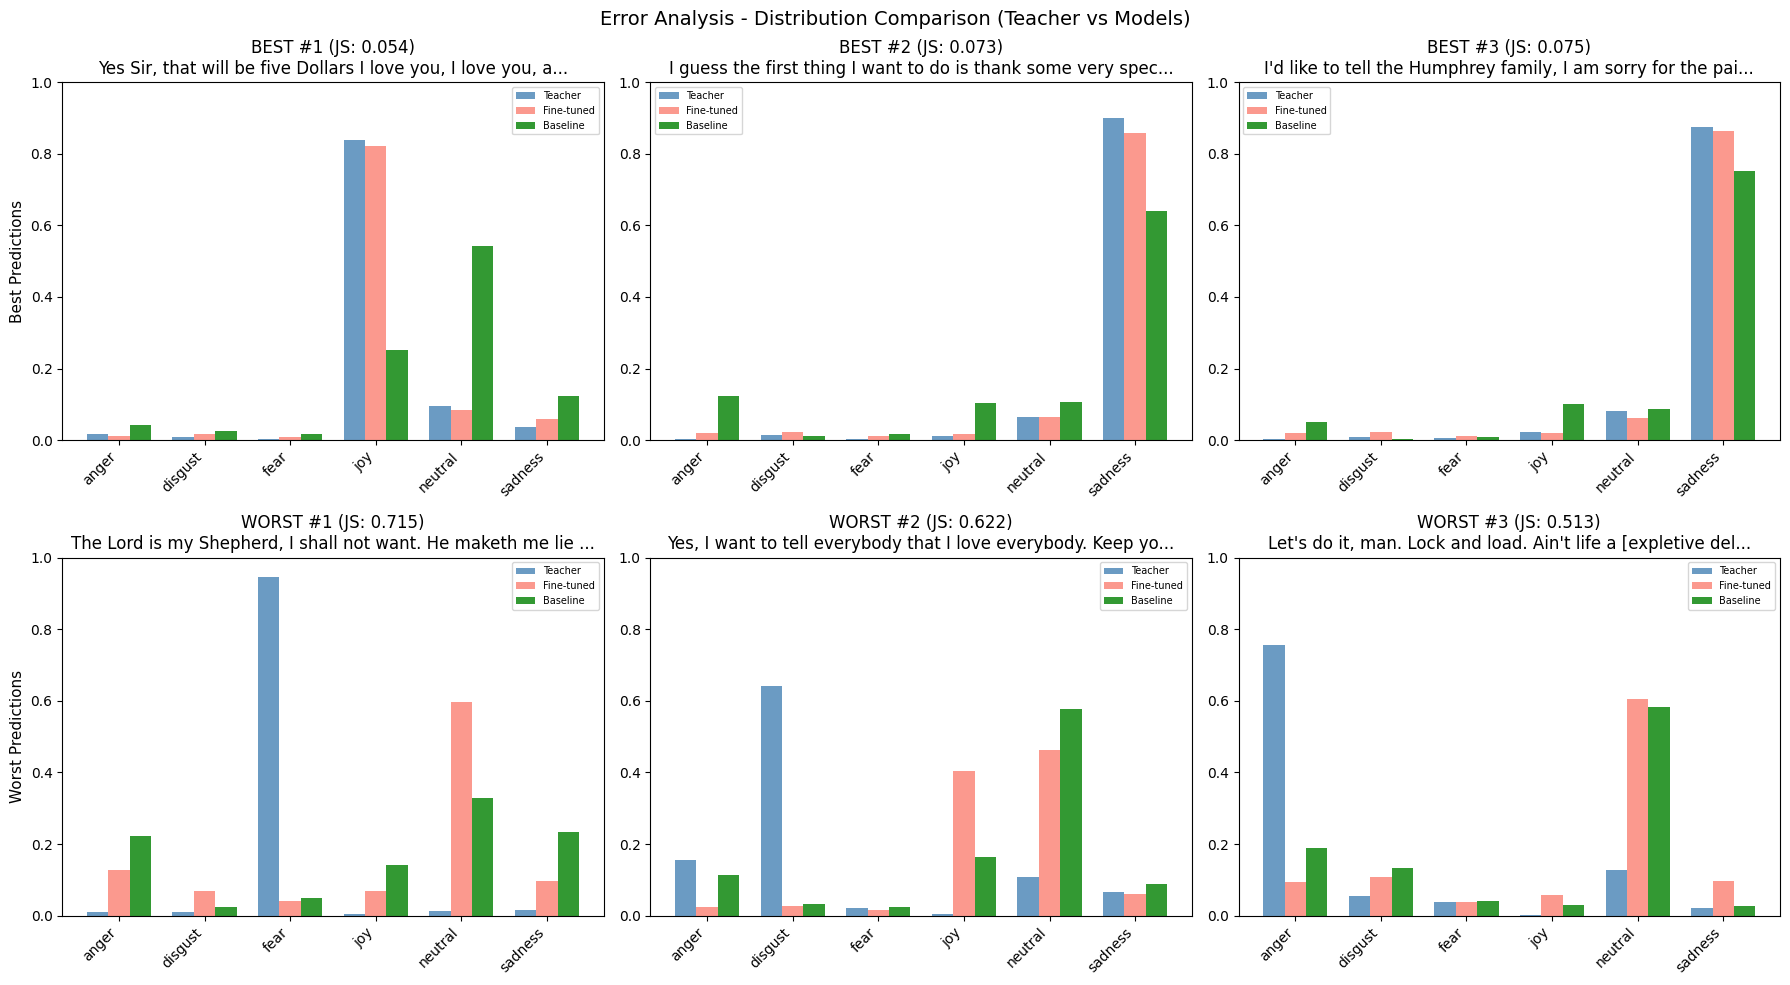

In [76]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

samples = list(best.head(3).iterrows())
for col, (_, row) in enumerate(samples):
    ax = axes[0, col]
    x  = np.arange(len(EMOTION_LABELS))
    ax.bar(x - 0.25, row['teacher_dist'], 0.25, label='Teacher',    color='steelblue', alpha=0.8)
    ax.bar(x,        row['dist_dist'],    0.25, label='Fine-tuned', color='salmon',    alpha=0.8)
    ax.bar(x + 0.25, row['base_dist'],    0.25, label='Baseline',   color='green',     alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(EMOTION_LABELS, rotation=45, ha='right')
    ax.set_title(f"BEST #{col+1} (JS: {row['dist_js']:.3f})\n{row['text'][:60]}...")
    ax.legend(fontsize=7)
    ax.set_ylim(0, 1)

samples = list(worst.head(3).iterrows())
for col, (_, row) in enumerate(samples):
    ax = axes[1, col]
    x  = np.arange(len(EMOTION_LABELS))
    ax.bar(x - 0.25, row['teacher_dist'], 0.25, label='Teacher',    color='steelblue', alpha=0.8)
    ax.bar(x,        row['dist_dist'],    0.25, label='Fine-tuned', color='salmon',    alpha=0.8)
    ax.bar(x + 0.25, row['base_dist'],    0.25, label='Baseline',   color='green',     alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(EMOTION_LABELS, rotation=45, ha='right')
    ax.set_title(f"WORST #{col+1} (JS: {row['dist_js']:.3f})\n{row['text'][:60]}...")
    ax.legend(fontsize=7)
    ax.set_ylim(0, 1)

axes[0, 0].set_ylabel('Best Predictions', fontsize=11)
axes[1, 0].set_ylabel('Worst Predictions', fontsize=11)

plt.suptitle('Error Analysis - Distribution Comparison (Teacher vs Models)', fontsize=14)
plt.tight_layout()
plt.show()

### Latent Space Projection (PCA)

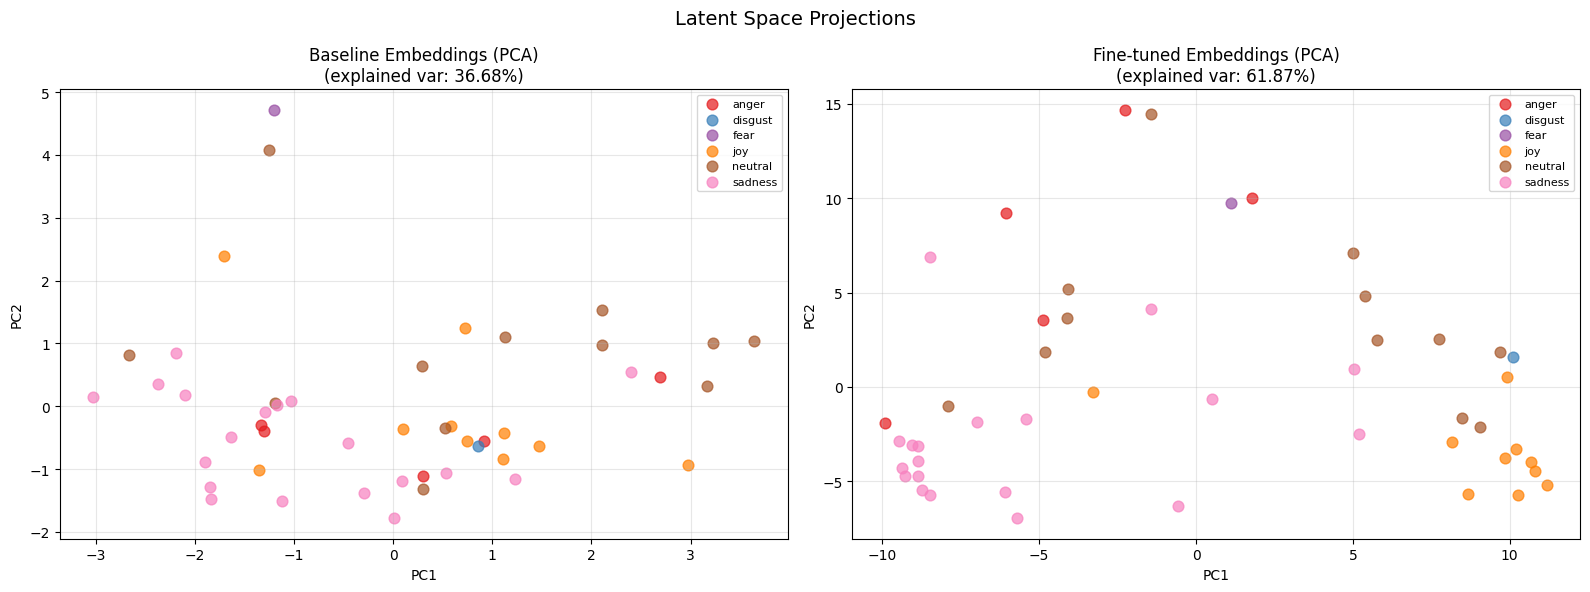

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = plt.cm.Set1(np.linspace(0, 1, 7))

base_emb,  base_preds,  soft_targets, hard_targets = extract_embeddings_and_preds(baseline_model,     test_loader, device)
dist_emb,  dist_preds,  _,            _            = extract_embeddings_and_preds(distillation_model, test_loader, device)


for ax, emb, title in zip(axes,
                           [base_emb, dist_emb],
                           ['Baseline Embeddings (PCA)', 'Fine-tuned Embeddings (PCA)']):
    pca   = PCA(n_components=2)
    proj  = pca.fit_transform(emb)
    for i, emotion in enumerate(EMOTION_LABELS):
        mask = hard_targets == i
        if mask.sum() > 0:
            ax.scatter(proj[mask, 0], proj[mask, 1], label=emotion, color=colors[i], alpha=0.7, s=60)
    
    ax.set_title(f"{title}\n(explained var: {pca.explained_variance_ratio_.sum():.2%})")
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Latent Space Projections', fontsize=14)
plt.tight_layout()
plt.show()

The PCA projections reveal a striking difference in how the two models organize their internal representations.
- Baseline (36.68% explained variance): The embeddings are tightly clustered in a small region with heavy overlap between emotion classes - sadness, neutral, and joy points are largely indistinguishable spatially. The low explained variance (36.68%) indicates the first two principal components capture relatively little of the embedding structure, meaning the frozen DistilBERT representations are not meaningfully organized around emotion in this domain. The embeddings are essentially general-purpose language representations that haven't adapted to the emotional content of last statements.
- Fine-tuned (61.87% explained variance): The explained variance jumps dramatically to 61.87%, meaning the fine-tuned model's embeddings have a much more structured geometry. The points are spread across a significantly larger space, and there is visible separation beginning to emerge - notably joy points cluster toward the bottom right, sadness points concentrate in the left and bottom left region, and neutral points occupy the upper areas. The model has reorganized its representation space around emotional content as a result of training on the soft label distributions.

The near-doubling of explained variance from 36.68% to 61.87% is a strong quantitative indicator that fine-tuning meaningfully restructured the embedding space around emotion rather than general language features. The persistent overlap between classes is consistent with the small dataset size and the inherently ambiguous emotional register of death row statements - many of which contain mixed emotions that even the teacher model labels with distributed probabilities rather than confident single-class assignments.

### Emotion Cluster Dendrograms

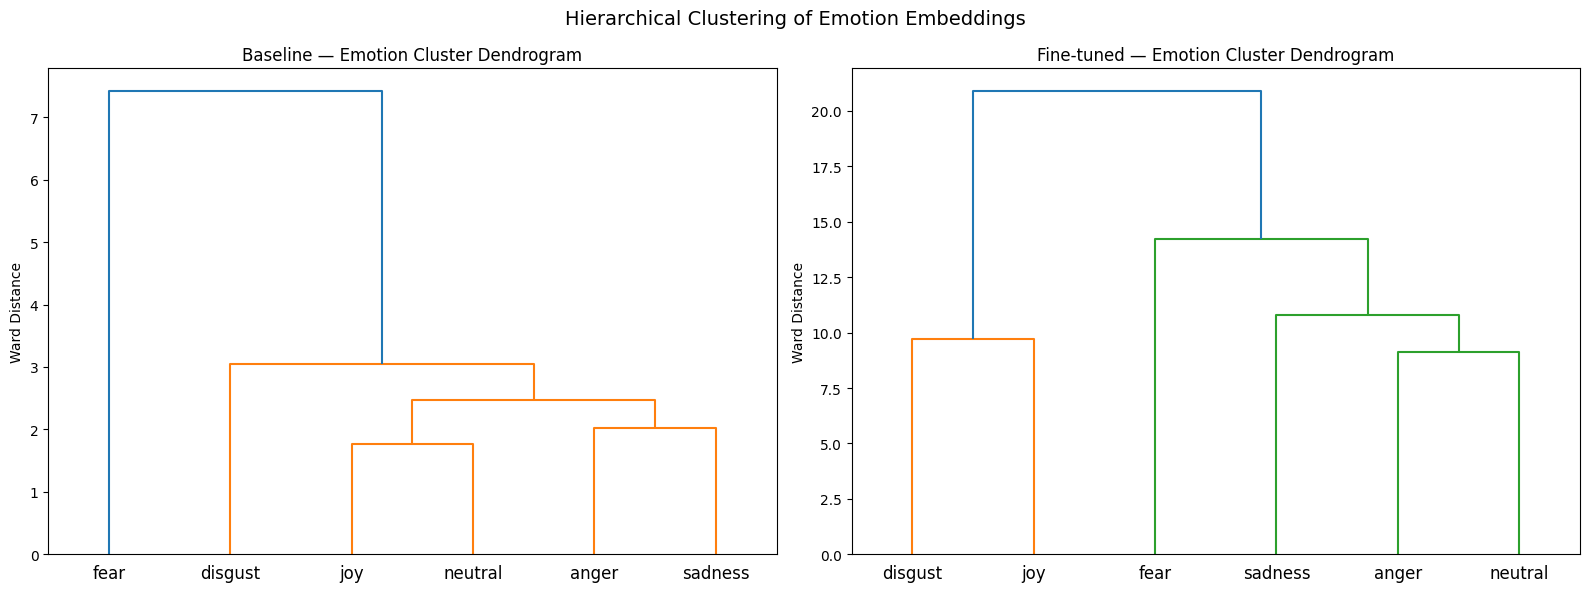

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, emb, title in zip(axes,
                           [base_emb, dist_emb],
                           ['Baseline', 'Fine-tuned']):
    # use mean embedding per emotion class as dendrogram leaves
    class_means = np.array([emb[hard_targets == i].mean(axis=0) 
                             for i in range(7) if (hard_targets == i).sum() > 0])
    class_names = [EMOTION_LABELS[i] 
                   for i in range(7) if (hard_targets == i).sum() > 0]
    
    Z = linkage(class_means, method='ward')
    dendrogram(Z, labels=class_names, ax=ax, color_threshold=0.7*max(Z[:,2]))
    ax.set_title(f'{title} - Emotion Cluster Dendrogram')
    ax.set_ylabel('Ward Distance')

plt.suptitle('Hierarchical Clustering of Emotion Embeddings', fontsize=14)
plt.tight_layout()
plt.show()

The hierarchical clustering dendrograms show how the models internally group emotion classes based on their mean embedding vectors, revealing fundamentally different organizational logic between the two models.
- Baseline: The dendrogram shows a binary split - fear stands completely alone on one side, while all other five emotions (disgust, joy, neutral, anger, sadness) are merged into a single undifferentiated cluster at low Ward distance. The internal structure of that cluster is also linguistically questionable: joy and neutral merge first, followed by anger and sadness merging together - pairings that make little intuitive sense emotionally. This confirms what the PCA showed: the frozen baseline's embeddings are not organized around emotional meaning, and the model essentially sees most emotions as variations of the same generic representation.
- Fine-tuned: The structure is substantially more interpretable. The dendrogram splits into two meaningful macro-clusters: disgust and joy on one side, and fear, sadness, anger, and neutral on the other. Within the second cluster, sadness and anger merge at low distance - which is emotionally coherent, as both are negative high-arousal states commonly co-occurring in last statements involving guilt and confrontation. Fear merging with sadness/anger also makes intuitive sense in this domain, as many statements contain elements of all three simultaneously. The notably higher Ward distances throughout indicate the fine-tuned embeddings are more spread out in space, consistent with the PCA findings.

### Clustering Metrics

In [78]:
def clustering_metrics(embeddings, labels, name):
    # need at least 2 classes present
    unique = np.unique(labels)
    if len(unique) < 2:
        print(f"{name}: not enough classes for clustering metrics")
        return {}
    
    sil = silhouette_score(embeddings, labels)
    db  = davies_bouldin_score(embeddings, labels)
    ch  = calinski_harabasz_score(embeddings, labels)
    
    print(f"\n{name}")
    print(f"  Silhouette Score:        {sil:.4f}")
    print(f"  Davies-Bouldin Score:    {db:.4f}")
    print(f"  Calinski-Harabasz Score: {ch:.4f}")
    
    return {'silhouette': sil, 'davies_bouldin': db, 'calinski_harabasz': ch}

base_cluster_metrics = clustering_metrics(base_emb, hard_targets, "Baseline")
dist_cluster_metrics = clustering_metrics(dist_emb, hard_targets, "Fine-tuned")



Baseline
  Silhouette Score:        -0.1078
  Davies-Bouldin Score:    2.6255
  Calinski-Harabasz Score: 1.9467

Fine-tuned
  Silhouette Score:        0.0284
  Davies-Bouldin Score:    1.7470
  Calinski-Harabasz Score: 5.5689


All three metrics consistently tell the same story across both models.
- Silhouette Score measures how well each point fits its own cluster versus neighboring clusters, ranging from -1 to 1. The baseline scores -0.1078, which is technically negative - meaning on average, embeddings are closer to a neighboring emotion cluster than their own. This is a quantitative confirmation that the frozen model produces no meaningful emotion separation whatsoever. The fine-tuned model improves to 0.0284, which while still close to zero, is positive - indicating at least marginal within-cluster cohesion has emerged after domain adaptation.
- Davies-Bouldin Score measures the average ratio of within-cluster scatter to between-cluster separation, where lower is better. The baseline scores 2.6255, reflecting highly overlapping, poorly separated clusters. The fine-tuned model drops to 1.7470 - a 33% improvement - indicating clusters are both tighter internally and more separated from each other.
- Calinski-Harabasz Score measures the ratio of between-cluster variance to within-cluster variance, where higher is better. The baseline scores just 1.9467, essentially indicating no meaningful cluster structure. The fine-tuned model nearly triples this to 5.5689, reflecting substantially better defined emotion groupings in the embedding space.

While neither model achieves strong absolute clustering performance - which is expected given the small test set size, class imbalance, and the inherently overlapping emotional content of last statements - the fine-tuned model improves on every single metric without exception. The direction of improvement is consistent and unambiguous, providing quantitative support for the qualitative observations made in the PCA and dendrogram analysis.

### Distribution matching metrics

In [81]:
def distribution_metrics(preds, soft_targets, hard_targets, name):
    js_divs  = [jensenshannon(soft_targets[i], preds[i]) for i in range(len(preds))]
    pearsons = [pearsonr(soft_targets[i], preds[i])[0]   for i in range(len(preds))]
    top1     = np.mean(np.argmax(preds, axis=1) == hard_targets)
    top2     = np.mean([
        set(np.argsort(soft_targets[i])[-2:]) == set(np.argsort(preds[i])[-2:])
        for i in range(len(preds))
    ])
    
    print(f"\n{name}")
    print(f"  Mean JS Divergence:  {np.mean(js_divs):.4f}")
    print(f"  Mean Pearson r:      {np.mean(pearsons):.4f}")
    print(f"  Top-1 Agreement:     {top1:.4f}")
    print(f"  Top-2 Agreement:     {top2:.4f}")
    
    return {'js_divergence': np.mean(js_divs), 'pearson': np.mean(pearsons),
            'top1': top1, 'top2': top2}

base_dist_metrics = distribution_metrics(base_preds, soft_targets, hard_targets, "Baseline")
dist_dist_metrics = distribution_metrics(dist_preds, soft_targets, hard_targets, "Fine-tuned")


Baseline
  Mean JS Divergence:  0.3180
  Mean Pearson r:      0.6257
  Top-1 Agreement:     0.5833
  Top-2 Agreement:     0.4583

Fine-tuned
  Mean JS Divergence:  0.2200
  Mean Pearson r:      0.7676
  Top-1 Agreement:     0.6667
  Top-2 Agreement:     0.5625


These four metrics directly measure how closely each model replicates j-hartmann's emotion distributions on the held-out test set, and represent the core quantitative result of the project.
- Jensen-Shannon Divergence measures the distance between the model's predicted distribution and the teacher's. The fine-tuned model achieves 0.2200 versus the baseline's 0.3180 - a 31% reduction in distributional distance. This is the single most important metric in this project given the distillation framing, and the improvement is substantial considering only 5 epochs of training on roughly 383 samples.
- Pearson Correlation measures how well the shape of the predicted distribution matches the teacher's across all 7 emotion dimensions. The baseline achieves 0.6257, which is a reasonable correlation for a frozen model, but the fine-tuned model improves to 0.7676 - indicating its predicted emotion profiles are significantly more aligned with j-hartmann's judgment of how emotions are distributed across each statement.
- Top-1 Agreement measures whether the dominant predicted emotion matches the teacher's. The baseline correctly identifies the dominant emotion 58.3% of the time, while the fine-tuned model reaches 66.7% - an 8 percentage point gain. Given the 7-class setting, random chance would be ~14.3%, so both models are well above chance, but the fine-tuned model's improvement is meaningful on this dataset size.
- Top-2 Agreement measures whether both models' top two predicted emotions match the teacher's top two. The baseline achieves 45.8% while the fine-tuned model reaches 56.25% - again a consistent improvement of roughly 10 percentage points.
- Key takeaway: The fine-tuned model outperforms the baseline on every distribution matching metric without exception, mirroring the clustering results. The improvement pattern is coherent - the model doesn't just get the dominant emotion right more often, it produces more accurate full distributions, suggesting genuine domain adaptation rather than a superficial label-matching effect. The remaining gap from perfect agreement is attributable to the small training set, 5-epoch training constraint, and the inherent ambiguity of emotionally complex last statements.

### Summary Table

In [80]:
all_metrics = pd.DataFrame({
    'Baseline':   {**base_cluster_metrics,  **base_dist_metrics},
    'Fine-tuned': {**dist_cluster_metrics,  **dist_dist_metrics}
}).T

print("\nSummary")
print(all_metrics.to_string())


Summary
            silhouette  davies_bouldin  calinski_harabasz  js_divergence   pearson      top1      top2
Baseline     -0.107821        2.625497           1.946697       0.317980  0.625702  0.583333  0.458333
Fine-tuned    0.028406        1.746978           5.568895       0.219962  0.767585  0.666667  0.562500


The consolidated summary table provides the clearest side-by-side view of the two models across all seven metrics, and the result is unambiguous - the fine-tuned model outperforms the baseline on every single metric without exception.

### Predicted distribution heatmaps

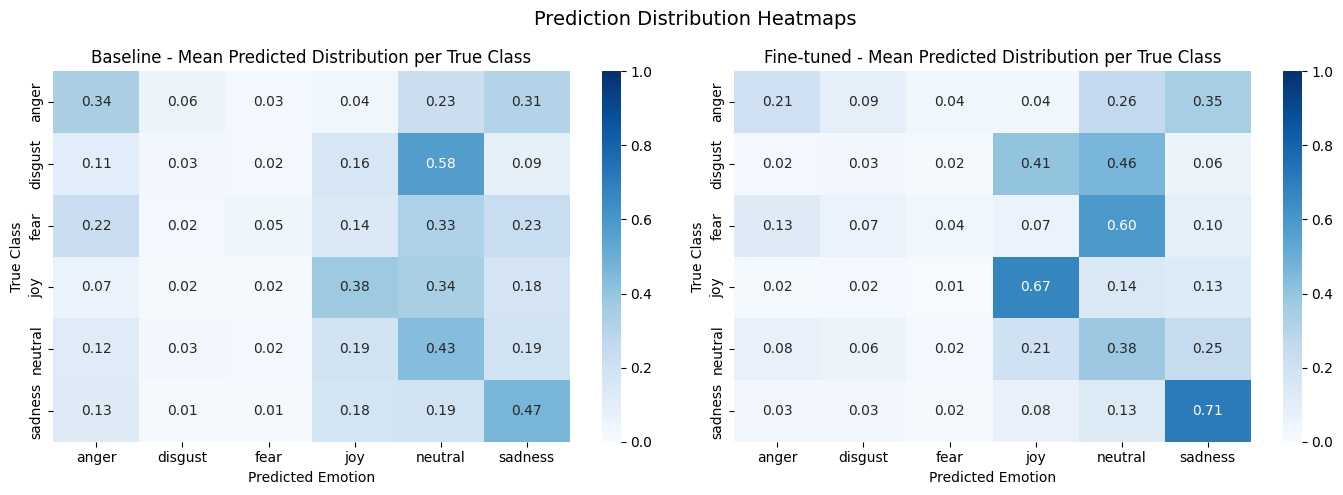

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, title in zip(axes,
                              [base_preds, dist_preds],
                              ['Baseline', 'Fine-tuned']):
    # mean predicted probability per true emotion class
    mean_dist = np.array([preds[hard_targets == i].mean(axis=0) 
                          for i in range(6) if (hard_targets == i).sum() > 0])
    present   = [EMOTION_LABELS[i] for i in range(7) if (hard_targets == i).sum() > 0]
    
    sns.heatmap(mean_dist, ax=ax, annot=True, fmt='.2f',
                xticklabels=EMOTION_LABELS, yticklabels=present,
                cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f'{title} - Mean Predicted Distribution per True Class')
    ax.set_xlabel('Predicted Emotion')
    ax.set_ylabel('True Class')

plt.suptitle('Prediction Distribution Heatmaps', fontsize=14)
plt.tight_layout()
plt.show()

- Baseline: The diagonal values are weak and inconsistent. The strongest diagonal entry is sadness at 0.57, but this is misleading given sadness is the the most over represented class in the dataset (189 entries). The frozen model essentially has a neutral and sadness bias that contaminates predictions across nearly every true class.
- Fine-tuned: The diagonal is visibly darker and more dominant across joy, neutral and sadness. Joy achieves the strongest diagonal at 0.67, sadness at 0.71 - both representing substantial improvements over the baseline's 0.38 and 0.47 respectively. The off-diagonal leakage into neutral is significantly reduced for sadness, joy, fear and disgust, confirming that fine-tuning specifically addressed the neutral bias present in the baseline.

### Jensen Shannon Divergence

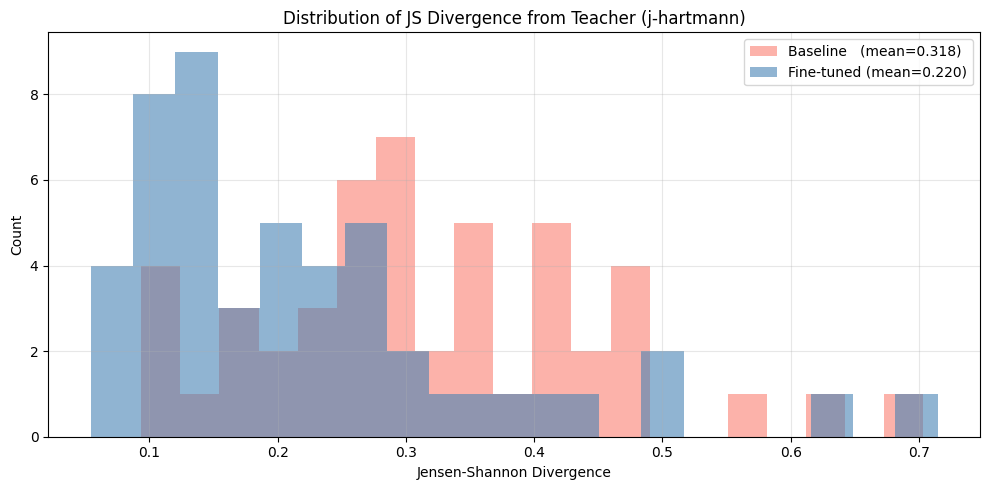

In [ ]:
base_js = [jensenshannon(soft_targets[i], base_preds[i]) for i in range(len(base_preds))]
dist_js = [jensenshannon(soft_targets[i], dist_preds[i]) for i in range(len(dist_preds))]

plt.figure(figsize=(10, 5))
plt.hist(base_js, bins=20, alpha=0.6, label=f'Baseline   (mean={np.mean(base_js):.3f})', color='salmon')
plt.hist(dist_js, bins=20, alpha=0.6, label=f'Fine-tuned (mean={np.mean(dist_js):.3f})', color='steelblue')
plt.xlabel('Jensen-Shannon Divergence')
plt.ylabel('Count')
plt.title('Distribution of JS Divergence from Teacher (j-hartmann)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The fine-tuned model's distribution shift is not merely a mean effect driven by a few outliers - the entire distribution has moved left. This is important because it means the improvement is broad and consistent rather than concentrated on easy cases. The overlapping region between 0.10–0.35 shows both models can handle straightforward emotionally clear statements similarly well, but the fine-tuned model handles the harder ambiguous cases significantly better as evidenced by its near-absence in the 0.30–0.70 range where the baseline still accumulates substantial counts.

## Conclusions
This project investigated whether domain-specific knowledge distillation could improve emotion recognition on death row last statements - a domain with no ground truth labels, highly specialized language, and inherent emotional ambiguity. By using j-hartmann as a teacher to generate soft label distributions and training DistilBERT as a student on those labels using KL divergence loss, the fine-tuned model outperformed the frozen baseline trained using Cross Entropy on all seven evaluation metrics, with the most notable gains being a 31% reduction in JS divergence, a 22% improvement in Pearson correlation, and a near-doubling of PCA explained variance indicating fundamentally restructured embeddings.

The primary limitation is that evaluation is entirely relative to the teacher - there is no human-annotated ground truth, meaning all conclusions describe how well the student replicates j-hartmann's judgment rather than how accurately it captures true emotion. The fine-tuned model also shows clear overfitting after epoch 2, which is expected when fine-tuning 67M parameters on 383 training samples. Fear and disgust were the hardest classes for both models, consistently confused with joy, sadness and neutral, reflecting the class imbalance in the training data.

The results support the core hypothesis: even with a small dataset and only 5 epochs of training, fine-tuning on domain-specific text produces measurably better calibrated emotion distributions than frozen general-purpose embeddings. The most valuable future direction would be human annotation of a subset of statements to enable absolute rather than relative evaluation.